# 线性回归

In [1]:
# 示例：某中学教师想研究学生每周学习时间（小时）与数学考试成绩（0-100分）之间的关系，并预测学生成绩。

In [2]:
from sklearn.linear_model import LinearRegression # 线性回归模型

In [3]:
# 1. 定义数据
# 自变量，每周学习时长
X = [[5], [8], [10], [12], [15], [3], [7], [9], [14], [6]]
# 因变量，数学考试成绩
y = [55, 65, 70, 75, 85, 50, 60, 72, 80, 58]

In [4]:
# 2. 定义模型
model = LinearRegression()

In [5]:
# 3. 训练模型
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
print("斜率:", model.coef_) # 斜率
print("截距:", model.intercept_) # 截距

斜率: [2.87070855]
截距: 41.45069393718042


In [7]:
# 4. 预测
x_new = [[11]]
y_pred = model.predict(x_new)
print(y_pred)

[73.02848795]


# 画图

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
x_line = np.arange(0, 18, 0.1).reshape(-1, 1) # np.arange(start, stop, step) 生成一个数组，start为起始值，stop为终止值，step为步长。reshape(-1, 1) 将数组转换为二维数组，-1表示自动计算行数，1表示列数为1。
y_line = model.predict(x_line)

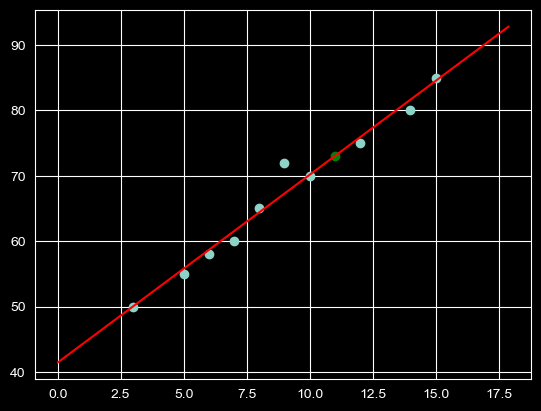

In [10]:
plt.scatter(X, y) # 绘制散点图
plt.plot(x_line, y_line, color='red') # 绘制回归直线
plt.scatter(x_new, y_pred, color='green') # 绘制预测点
plt.show()

In [12]:
# 5. 模型评估
print("R^2:", model.score(X, y)) # R^2: 决定系数，表示模型对数据的拟合程度，取值范围为0-1，越接近1表示拟合越好。R^2 = 1 - (残差平方和 / 总平方和) = 1 - (Σ(y_i - ŷ_i)^2 / Σ(y_i - ȳ)^2) 意思是模型对数据的拟合程度，越接近1表示拟合越好。

R^2: 0.9742560092651116


# 验证模型求解

In [15]:
x = np.array(X).reshape(-1) # 将二维数组转换为一维数组
print(x)

[ 5  8 10 12 15  3  7  9 14  6]


In [19]:
cov = np.cov(x, y) # 计算协方差矩阵，np.cov(x, y) 返回一个2x2的矩阵，其中cov[0, 1]表示x和y的协方差，cov[0, 0]表示x的方差，cov[1, 1]表示y的方差。
print(cov)

[[ 15.21111111  43.66666667]
 [ 43.66666667 128.66666667]]


In [21]:
beta1 = cov[0][1] / cov[0][0] # 斜率 = 协方差 / 方差
print(beta1)

2.8707085463842223


In [24]:
beta0 = np.mean(y) - beta1 * np.mean(x) # 截距 = y的均值 - 斜率 * x的均值
print(beta0)

41.45069393718042
